<a href="https://colab.research.google.com/github/Varalakshmi-skab/datasciencelearning/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [24]:
df=pd.read_csv("/content/drive/MyDrive/Datasets for datascience/height-weight (1).csv")
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [25]:
df.isnull().sum() #check null values
df.duplicated() #check for duplicates
df.drop_duplicates() #removing the duplicates
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Weight  23 non-null     int64
 1   Height  23 non-null     int64
dtypes: int64(2)
memory usage: 500.0 bytes


In [26]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


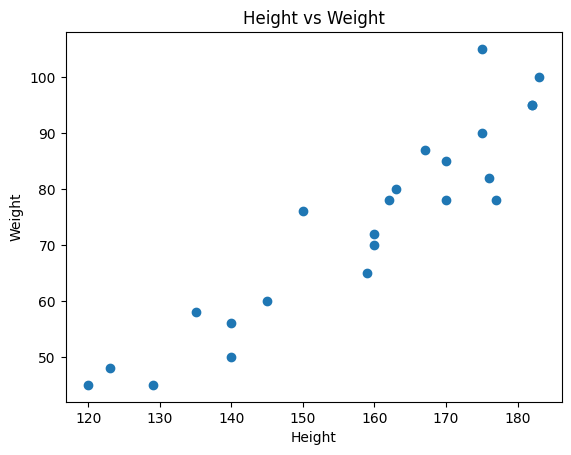

In [27]:
plt.scatter(df['Height'],df['Weight'])
plt.xlabel('Height')
plt.ylabel('Weight')
plt.title('Height vs Weight')
plt.show()

In [ ]:
df.describe()

**x** => Features (independent variables)

**y** => Target (dependent variable)

In [ ]:
X=df[["Weight"]]
print(X.shape)
Y=df[["Height"]]
print(X)

In [30]:
X_train,X_test,Y_train,Y_test=train_test_split(
    X,
    Y,
    test_size=0.3,
    random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

In [ ]:
scalar=StandardScaler()
X_train=scalar.fit_transform(X_train)
X_test=scalar.transform(X_test)
print(X_train)

In [ ]:
model=LinearRegression()
model.fit(X_train,Y_train)

In [ ]:
print("Intercept",model.intercept_)
print("coefficient",model.coef_)

In [43]:
#checking training performance
y_train_pridict=model.predict(X_train)
training_acc=r2_score(Y_train,y_train_pridict)
print("Training Accuracy",training_acc)

Training Accuracy 0.9219434200124264


In [39]:
y_pred=model.predict(X_test)
testing_acc=r2_score(Y_test,y_pred)
print("Testing Accuracy",testing_acc)

Testing Accuracy 0.7828485570493535


In [50]:
mae=mean_absolute_error(Y_test,y_pred)
mse= mean_squared_error(Y_test,y_pred)
rmse=np.sqrt(mse)
print("Mean Absolute Error",mae)
print("Mean Squared Error",mse)
print("Root Mean Squared Error",rmse)

Mean Absolute Error 9.237776679921925
Mean Squared Error 103.09818711844574
Root Mean Squared Error 10.153727744944009


In [53]:
new_weight=[[72]]
scale=scalar.transform(new_weight)
predicted_height=model.predict(scale)
print("Predicted Height",predicted_height[0])

Predicted Height [1384.1220672]


In [54]:
import pickle
pickle.dump(scalar,open('scalar.pkl','wb'))
pickle.dump(model,open('weightheightpredmodel.pkl','wb'))